In [1]:
# Imports
from google.colab import drive
import os
import scipy.sparse as sp
import joblib
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report
from tqdm import tqdm #add a visual progress bar to loops
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
# Mount drive, if needed
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Path to Google Drive project directory
drive_project_dir = '/content/drive/MyDrive/twitter-multimodal-hate-speech-classifier'

# Set project directory as current working directory
os.chdir(drive_project_dir)

# Set path to directory with data files in Google Drive
drive_data_dir = 'data' # relative path
os.makedirs(drive_data_dir, exist_ok=True)

# Set path to directory with trained models in Google Drive
drive_models_dir = 'models'
os.makedirs(drive_models_dir, exist_ok=True)

# Set path to directory with reports (plots, tables) in Google Drive
drive_reports_dir = 'reports'
os.makedirs(drive_reports_dir, exist_ok=True)

In [4]:
# Import utils
from src.model_utils import merge_results, plot_side_by_side_confusion_matrices

In [5]:
# Load preprocessed train, validation, test data and their target labels

# Preprocessing + Bag of Words vectorization: sparse
X_train_bow_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_train_bow_processed_matrix.npz'))
X_val_bow_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_val_bow_processed_matrix.npz'))
#X_test_bow_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_test_bow_processed_matrix.npz'))

# Preprocessing + TF-IDF vectorizaton: sparse
X_train_tfidf_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_train_tfidf_processed_matrix.npz'))
X_val_tfidf_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_val_tfidf_processed_matrix.npz'))
#X_test_tfidf_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_test_tfidf_processed_matrix.npz'))

# Preprocessing + TF-IDF (with ngrams) vectorization: sparse
X_train_tfidf_ngram_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_train_tfidf_ngram_processed_matrix.npz'))
X_val_tfidf_ngram_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_val_tfidf_ngram_processed_matrix.npz'))
#X_test_tfidf_ngram_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_test_tfidf_ngram_processed_matrix.npz'))

# Processing + RoBERTa embedding: dense
X_train_roberta_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_train_roberta_processed_matrix.npz'))
X_val_roberta_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_val_roberta_processed_matrix.npz'))
#X_test_roberta_processed_matrix = sp.load_npz(os.path.join(drive_data_dir, 'X_test_roberta_processed_matrix.npz'))

# Labels
y_train = pd.read_parquet(os.path.join(drive_data_dir, 'y_train.parquet'))['target']
y_val = pd.read_parquet(os.path.join(drive_data_dir, 'y_val.parquet'))['target']
y_test = pd.read_parquet(os.path.join(drive_data_dir, 'y_test.parquet'))['target']

# Feature names
feature_names_tfidf = joblib.load(os.path.join(drive_data_dir, 'feature_names_tfidf_processed.joblib'))

In [10]:
# Define label map to encode numeric labels into string
label_map = {0: 'NotHate', 1: 'Racist', 2: 'Sexist', 3: 'Homophobe', 4: 'Religion', 5: 'OtherHate'}

In [11]:
# Initialize list to store model performance results
results_list = []

## Вибір метрик оцінювання моделей

У цій роботі ми працюємо з багатокласовою сильно незбалансованою проблемою. Основною метрикою для оцінки якості передбачень моделей у цій роботі обрано `macro avg F1-score`. Ця метрика представляє незважене середнє значення F1-score усіх цільових класів - кожен з класів, незалежно від своєї величинии, впливає на метрику однаково. Таким чином `macro avg F1-score` дає можливість оцінити якість передбачень моделі для рідких (нечисельих) класів нарівні з домінуючими класами.
Загальна якість зроблених передбачень буде оцінюватись метрикою `weighted avg F1-score` (другорядна метрика).


## 0.BoW + Logistic regression (baseline model)

In [ ]:
# Setup Logistic regression model (baseline)
model_logreg_bow = LogisticRegression(
    max_iter=1000,
    solver='sag',
    C=0.1,
    class_weight='balanced',
    random_state=42)

In [ ]:
# Fit model on train dataset
%%time
model_logreg_bow.fit(X_train_bow_processed_matrix, y_train)

CPU times: user 3min 19s, sys: 172 ms, total: 3min 19s
Wall time: 3min 25s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='sag')

In [ ]:
# Save trained model
joblib.dump(model_logreg_bow, os.path.join(drive_models_dir, 'model_logreg_bow.joblib'))

['/content/drive/MyDrive/ML_course/Final-Project/models/model_logreg_bow.joblib']

In [ ]:
# Predict labels for train and validation data
train_pred_classes_logreg_bow = model_logreg_bow.predict(X_train_bow_processed_matrix)
val_pred_classes_logreg_bow = model_logreg_bow.predict(X_val_bow_processed_matrix)

In [ ]:
# Evaluate model's performance on train data
print(classification_report(y_train, train_pred_classes_logreg_bow, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.96      0.59      0.73    105346
      Racist       0.26      0.69      0.38      9503
      Sexist       0.17      0.89      0.29      2790
   Homophobe       0.40      0.97      0.56      3087
    Religion       0.25      1.00      0.40       131
   OtherHate       0.31      0.89      0.46      4645

    accuracy                           0.62    125502
   macro avg       0.39      0.84      0.47    125502
weighted avg       0.85      0.62      0.68    125502



In [ ]:
# Evaluate model's performance on validation data
print(classification_report(y_val, val_pred_classes_logreg_bow, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.80      0.57      0.67      2500
      Racist       0.48      0.54      0.51       809
      Sexist       0.30      0.62      0.40       241
   Homophobe       0.60      0.91      0.72       252
    Religion       0.22      0.56      0.31         9
   OtherHate       0.51      0.78      0.62       386

    accuracy                           0.61      4197
   macro avg       0.48      0.66      0.54      4197
weighted avg       0.67      0.61      0.62      4197



In [ ]:
# Store models performace indices to the list
res = merge_results(
    model_name = 'BoW + Log. reg. (baseline)',
    model = model_logreg_bow,
    y_train = y_train,
    train_pred_classes = train_pred_classes_logreg_bow,
    y_val = y_val,
    val_pred_classes = val_pred_classes_logreg_bow
    )

results_list.append(res)

## 1.TF-IDF + XGBoost

In [ ]:
# Compute sample weights for current imbalanced multiclass problem
sample_weights = compute_sample_weight('balanced', y_train)

In [ ]:
# Setup XGBoost model
model_xgb_tfidf = xgb.XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    colsample_bytree=0.4,
    subsample=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    early_stopping_rounds=25,
    tree_method="hist",
    device="cuda",
    random_state=42
)

In [ ]:
# Fit model on train dataset
%%time
model_xgb_tfidf.fit(X_train_tfidf_processed_matrix, y_train, eval_set=[(X_val_tfidf_processed_matrix, y_val)], sample_weight=sample_weights, verbose=True)

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [08:06:49] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [08:06:49] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:1.73237
[1]	validation_0-mlogloss:1.67686
[2]	validation_0-mlogloss:1.65607
[3]	validation_0-mlogloss:1.60828
[4]	validation_0-mlogloss:1.59617
[5]	validation_0-mlogloss:1.56112
[6]	validation_0-mlogloss:1.54697
[7]	validation_0-mlogloss:1.50983
[8]	validation_0-mlogloss:1.48000
[9]	validation_0-mlogloss:1.46245
[10]	validation_0-mlogloss:1.43774
[11]	validation_0-mlogloss:1.42283
[12]	validation_0-mlogloss:1.40364
[13]	validation_0-mlogloss:1.39174
[14]	validation_0-mlogloss:1.37131
[15]	validation_0-mlogloss:1.35216
[16]	validation_0-mlogloss:1.33258
[17]	validation_0-mlogloss:1.32148
[18]	validation_0-mlogloss:1.30501
[19]	validation_0-mlogloss:1.29295
[20]	validation_0-mlogloss:1.28567
[21]	validation_0-mlogloss:1.27084
[22]	validation_0-mlogloss:1.26126
[23]	validation_0-mlogloss:1.25292
[24]	validation_0-mlogloss:1.24074
[25]	validation_0-mlogloss:1.22974
[26]	validation_0-mlogloss:1.22051
[27]	validation_0-mlogloss:1.21335
[28]	validation_0-mlogloss:1.2

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device='cuda', early_stopping_rounds=25,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Save trained model
joblib.dump(model_xgb_tfidf, os.path.join(drive_models_dir,'model_xgb_tfidf.joblib'))

['/content/drive/MyDrive/ML_course/Final-Project/models/model_xgb_tfidf.joblib']

In [ ]:
# Predict labels for train and validation data
train_pred_classes_xgb_tfidf = model_xgb_tfidf.predict(X_train_tfidf_processed_matrix)
val_pred_classes_xgb_tfidf = model_xgb_tfidf.predict(X_val_tfidf_processed_matrix)

In [ ]:
# Evaluate model's performance on train data
print(classification_report(y_train, train_pred_classes_xgb_tfidf, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.94      0.65      0.77    105346
      Racist       0.36      0.50      0.42      9503
      Sexist       0.13      0.83      0.23      2790
   Homophobe       0.36      0.97      0.52      3087
    Religion       0.24      1.00      0.39       131
   OtherHate       0.28      0.81      0.41      4645

    accuracy                           0.65    125502
   macro avg       0.39      0.79      0.46    125502
weighted avg       0.84      0.65      0.71    125502



In [ ]:
# Evaluate model's performance on validation data
print(classification_report(y_val, val_pred_classes_xgb_tfidf, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.81      0.65      0.72      2500
      Racist       0.61      0.46      0.52       809
      Sexist       0.33      0.80      0.46       241
   Homophobe       0.60      0.97      0.74       252
    Religion       0.33      0.56      0.42         9
   OtherHate       0.55      0.80      0.65       386

    accuracy                           0.65      4197
   macro avg       0.54      0.71      0.59      4197
weighted avg       0.70      0.65      0.66      4197



In [ ]:
# Store models performace indices to the list
res = merge_results(
    model_name = 'TF-IDF + XGBoost',
    model = model_xgb_tfidf,
    y_train = y_train,
    train_pred_classes = train_pred_classes_xgb_tfidf,
    y_val = y_val,
    val_pred_classes = val_pred_classes_xgb_tfidf
    )

results_list.append(res)

## 2.RoBERTa + XGBoost

In [ ]:
# Compute sample weights for current imbalanced multiclass problem
sample_weights = compute_sample_weight('balanced', y_train)

In [ ]:
# Setup XGBoost model
model_xgb_roberta = xgb.XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    colsample_bytree=0.4,  # 40% of features per tree (vital for embeddings)
    subsample=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    early_stopping_rounds=25,
    tree_method="hist",
    device="cuda",
    random_state=42
)

In [ ]:
# Fit model on train dataset
%%time
model_xgb_roberta.fit(X_train_roberta_processed_matrix, y_train, eval_set=[(X_val_roberta_processed_matrix, y_val)], sample_weight=sample_weights, verbose=True)

[0]	validation_0-mlogloss:1.76752
[1]	validation_0-mlogloss:1.73296
[2]	validation_0-mlogloss:1.70151
[3]	validation_0-mlogloss:1.68071
[4]	validation_0-mlogloss:1.64904
[5]	validation_0-mlogloss:1.62569
[6]	validation_0-mlogloss:1.60509
[7]	validation_0-mlogloss:1.58253
[8]	validation_0-mlogloss:1.56343
[9]	validation_0-mlogloss:1.54582
[10]	validation_0-mlogloss:1.52895
[11]	validation_0-mlogloss:1.51400
[12]	validation_0-mlogloss:1.49844
[13]	validation_0-mlogloss:1.48605
[14]	validation_0-mlogloss:1.47645
[15]	validation_0-mlogloss:1.46594
[16]	validation_0-mlogloss:1.45534
[17]	validation_0-mlogloss:1.44443
[18]	validation_0-mlogloss:1.43471
[19]	validation_0-mlogloss:1.42465
[20]	validation_0-mlogloss:1.41782
[21]	validation_0-mlogloss:1.41101
[22]	validation_0-mlogloss:1.40374
[23]	validation_0-mlogloss:1.39617
[24]	validation_0-mlogloss:1.38878
[25]	validation_0-mlogloss:1.37925
[26]	validation_0-mlogloss:1.36915
[27]	validation_0-mlogloss:1.36155
[28]	validation_0-mlogloss:1.3

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device='cuda', early_stopping_rounds=25,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Save trained model
joblib.dump(model_xgb_roberta, os.path.join(drive_models_dir, 'model_xgb_roberta.joblib'))

['/content/drive/MyDrive/ML_course/Final-Project/models/model_xgb_roberta.joblib']

In [ ]:
# Predict labels for train and validation data
train_pred_classes_xgb_roberta = model_xgb_roberta.predict(X_train_roberta_processed_matrix)
val_pred_classes_xgb_roberta = model_xgb_roberta.predict(X_val_roberta_processed_matrix)

In [ ]:
# Evaluate model's performance on train data
print(classification_report(y_train, train_pred_classes_xgb_roberta, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.95      0.60      0.73    105346
      Racist       0.24      0.54      0.34      9503
      Sexist       0.16      0.80      0.27      2790
   Homophobe       0.34      0.87      0.49      3087
    Religion       0.28      1.00      0.44       131
   OtherHate       0.25      0.85      0.39      4645

    accuracy                           0.62    125502
   macro avg       0.37      0.78      0.44    125502
weighted avg       0.84      0.62      0.67    125502



In [ ]:
# Evaluate model's performance on validation data
print(classification_report(y_val, val_pred_classes_xgb_roberta, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.79      0.59      0.67      2500
      Racist       0.41      0.40      0.40       809
      Sexist       0.32      0.60      0.41       241
   Homophobe       0.48      0.76      0.59       252
    Religion       0.23      0.33      0.27         9
   OtherHate       0.45      0.77      0.57       386

    accuracy                           0.58      4197
   macro avg       0.45      0.58      0.49      4197
weighted avg       0.64      0.58      0.59      4197



In [ ]:
# Store models performace indices to the list
res = merge_results(
    model_name = 'RoBERTa + XGBoost',
    model = model_xgb_roberta,
    y_train = y_train,
    train_pred_classes = train_pred_classes_xgb_roberta,
    y_val = y_val,
    val_pred_classes = val_pred_classes_xgb_roberta
    )

results_list.append(res)

## 3.TF-IDF (ngram) + Linear SVC

In [ ]:
# Setup Linear SVC model
model_linsvm_tfidf_ngram = LinearSVC(
    C=0.01,
    penalty='l1', # for sparse embeddings
    class_weight='balanced',
    dual='auto',
    max_iter=3000,
    random_state=42
)

In [ ]:
# Fit model on train dataset
%%time
model_linsvm_tfidf_ngram.fit(X_train_tfidf_ngram_processed_matrix, y_train)

CPU times: user 7.79 s, sys: 202 ms, total: 7.99 s
Wall time: 8 s


LinearSVC(C=0.01, class_weight='balanced', max_iter=3000, penalty='l1',
          random_state=42)

In [ ]:
# Save trained model
joblib.dump(model_linsvm_tfidf_ngram, os.path.join(drive_models_dir, 'model_linsvm_tfidf_ngram.joblib'))

['/content/drive/MyDrive/ML_course/Final-Project/models/model_linsvm_tfidf_ngram.joblib']

In [ ]:
# Predict labels for train and validation data
train_pred_classes_linsvm_tfidf_ngram = model_linsvm_tfidf_ngram.predict(X_train_tfidf_ngram_processed_matrix)
val_pred_classes_linsvm_tfidf_ngram = model_linsvm_tfidf_ngram.predict(X_val_tfidf_ngram_processed_matrix)

In [ ]:
# Evaluate model's performance on train data
print(classification_report(y_train, train_pred_classes_linsvm_tfidf_ngram, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.90      0.85      0.88    105346
      Racist       0.49      0.27      0.35      9503
      Sexist       0.18      0.38      0.24      2790
   Homophobe       0.42      0.85      0.56      3087
    Religion       0.17      0.79      0.27       131
   OtherHate       0.37      0.65      0.47      4645

    accuracy                           0.79    125502
   macro avg       0.42      0.63      0.46    125502
weighted avg       0.82      0.79      0.80    125502



In [ ]:
# Evaluate model's performance on validation data
print(classification_report(y_val, val_pred_classes_linsvm_tfidf_ngram, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.72      0.85      0.78      2500
      Racist       0.74      0.26      0.39       809
      Sexist       0.40      0.39      0.40       241
   Homophobe       0.66      0.83      0.73       252
    Religion       0.26      0.56      0.36         9
   OtherHate       0.65      0.65      0.65       386

    accuracy                           0.69      4197
   macro avg       0.57      0.59      0.55      4197
weighted avg       0.70      0.69      0.67      4197



In [ ]:
# Store models performace indices to the list
res = merge_results(
    model_name = 'TF-IDF(ngram) + Linear SVC',
    model = model_linsvm_tfidf_ngram,
    y_train = y_train,
    train_pred_classes = train_pred_classes_linsvm_tfidf_ngram,
    y_val = y_val,
    val_pred_classes = val_pred_classes_linsvm_tfidf_ngram
    )

results_list.append(res)

## 4.RoBERTa + Linear SVC

In [ ]:
# Setup Linear SVC model
model_linsvm_roberta = LinearSVC(
    C=0.01,
    penalty='l2', # for dense embeddings
    class_weight='balanced',
    dual=False,
    max_iter=2000,
    random_state=42
)

In [ ]:
# Fit model on train dataset
%%time
model_linsvm_roberta.fit(X_train_roberta_processed_matrix, y_train)

CPU times: user 4min, sys: 883 ms, total: 4min 1s
Wall time: 4min 7s


LinearSVC(C=0.01, class_weight='balanced', dual=False, max_iter=2000,
          random_state=42)

In [ ]:
# Save trained model
joblib.dump(model_linsvm_roberta, os.path.join(drive_models_dir, 'model_linsvm_roberta.joblib'))

['/content/drive/MyDrive/ML_course/Final-Project/models/model_linsvm_roberta.joblib']

In [ ]:
# Predict labels for train and validation data
train_pred_classes_linsvm_roberta = model_linsvm_roberta.predict(X_train_roberta_processed_matrix)
val_pred_classes_linsvm_roberta = model_linsvm_roberta.predict(X_val_roberta_processed_matrix)

In [ ]:
# Evaluate model's performance on train data
print(classification_report(y_train, train_pred_classes_linsvm_roberta, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.91      0.83      0.87    105346
      Racist       0.45      0.27      0.34      9503
      Sexist       0.21      0.42      0.28      2790
   Homophobe       0.39      0.79      0.52      3087
    Religion       0.13      0.95      0.23       131
   OtherHate       0.29      0.70      0.41      4645

    accuracy                           0.77    125502
   macro avg       0.40      0.66      0.44    125502
weighted avg       0.83      0.77      0.79    125502



In [ ]:
# Evaluate model's performance on validation data
print(classification_report(y_val, val_pred_classes_linsvm_roberta, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.74      0.82      0.78      2500
      Racist       0.68      0.27      0.39       809
      Sexist       0.38      0.36      0.37       241
   Homophobe       0.58      0.78      0.67       252
    Religion       0.10      0.44      0.16         9
   OtherHate       0.52      0.69      0.59       386

    accuracy                           0.67      4197
   macro avg       0.50      0.56      0.49      4197
weighted avg       0.68      0.67      0.65      4197



In [ ]:
# Store models performace indices to the list
res = merge_results(
    model_name = 'RoBERTa + Linear SVC',
    model = model_linsvm_roberta,
    y_train = y_train,
    train_pred_classes = train_pred_classes_linsvm_roberta,
    y_val = y_val,
    val_pred_classes = val_pred_classes_linsvm_roberta
    )

results_list.append(res)

## 5.RoBERTa + SGDClassifier (Gradient Descent)

In [ ]:
# Setup Linear SVC model
model_sgd_roberta = SGDClassifier(
        loss='hinge',
        penalty='l2',
        alpha=1e-4,
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=1
    )

In [ ]:
# Fit model on train dataset
%%time
model_sgd_roberta.fit(X_train_roberta_processed_matrix, y_train)

CPU times: user 1min 31s, sys: 78.9 ms, total: 1min 31s
Wall time: 1min 33s


SGDClassifier(class_weight='balanced', n_jobs=1, random_state=42)

In [ ]:
# Save trained model
joblib.dump(model_sgd_roberta, os.path.join(drive_models_dir, 'model_sgd_roberta.joblib'))

['/content/drive/MyDrive/ML_course/Final-Project/models/model_sgd_roberta.joblib']

In [ ]:
# Predict labels for train and validation data
train_pred_classes_sgd_roberta = model_sgd_roberta.predict(X_train_roberta_processed_matrix)
val_pred_classes_sgd_roberta = model_sgd_roberta.predict(X_val_roberta_processed_matrix)

In [ ]:
# Evaluate model's performance on train data
print(classification_report(y_train, train_pred_classes_sgd_roberta, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.92      0.81      0.86    105346
      Racist       0.42      0.27      0.33      9503
      Sexist       0.19      0.52      0.28      2790
   Homophobe       0.26      0.87      0.40      3087
    Religion       0.05      0.98      0.10       131
   OtherHate       0.38      0.53      0.44      4645

    accuracy                           0.75    125502
   macro avg       0.37      0.66      0.40    125502
weighted avg       0.83      0.75      0.78    125502



In [ ]:
# Evaluate model's performance on validation data
print(classification_report(y_val, val_pred_classes_sgd_roberta, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.75      0.80      0.77      2500
      Racist       0.64      0.24      0.35       809
      Sexist       0.37      0.44      0.40       241
   Homophobe       0.41      0.87      0.56       252
    Religion       0.05      0.56      0.09         9
   OtherHate       0.63      0.48      0.54       386

    accuracy                           0.64      4197
   macro avg       0.47      0.56      0.45      4197
weighted avg       0.67      0.64      0.63      4197



In [ ]:
# Store models performace indices to the list
res = merge_results(
    model_name = 'RoBERTa + SGDClassifier',
    model = model_sgd_roberta,
    y_train = y_train,
    train_pred_classes = train_pred_classes_sgd_roberta,
    y_val = y_val,
    val_pred_classes = val_pred_classes_sgd_roberta
    )

results_list.append(res)

## Аналіз якості передбачень моделей

### Загальна таблиця результатів

In [ ]:
# Convert list of dictionaries with model performance scores into a DataFrame
results_df = pd.DataFrame(results_list)

In [ ]:
# Display scores table, highlighting the best macro F1 on validation data in green
(results_df.style.highlight_max(subset=['Macro_F1_val'], color='lightgreen').format(precision=4))

,Model_name,Hyperparameters,Macro_F1_train,Macro_F1_val,Weighted_F1_train,Weighted_F1_val
0,BoW + Log. reg. (baseline),"{'C': 0.1, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'sag', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}",0.4711,0.5389,0.6791,0.6208
1,TF-IDF + XGBoost,"{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.4, 'device': 'cuda', 'early_stopping_rounds': 25, 'enable_categorical': True, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 1.0, 'reg_lambda': 2.0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}",0.4571,0.5827,0.7096,0.6628
2,RoBERTa + XGBoost,"{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.4, 'device': 'cuda', 'early_stopping_rounds': 25, 'enable_categorical': True, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 1.0, 'reg_lambda': 2.0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}",0.4415,0.4875,0.6744,0.5913
3,TF-IDF(ngram) + Linear SVC,"{'C': 0.01, 'class_weight': 'balanced', 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 3000, 'multi_class': 'ovr', 'penalty': 'l1', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}",0.4613,0.5507,0.7978,0.6677
4,RoBERTa + Linear SVC,"{'C': 0.01, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 2000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}",0.4418,0.4927,0.7905,0.6536
5,RoBERTa + SGDClassifier,"{'alpha': 0.0001, 'average': False, 'class_weight': 'balanced', 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.0, 'fit_intercept': True, 'l1_ratio': 0.15, 'learning_rate': 'optimal', 'loss': 'hinge', 'max_iter': 1000, 'n_iter_no_change': 5, 'n_jobs': -1, 'penalty': 'l2', 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}",0.4016,0.4513,0.7781,0.6341


In [ ]:
# Optional: save as .csv
results_df.to_csv(os.path.join(drive_reports_dir, 'model_performance_results.csv'), index=False)

Модель TF-IDF + XGBoost показала найкращий результат на валідаційних даних по головній метриці `macro avg F1-score`. Оцінюючи різні метрики моделей, можна побачити цікавий паттерн: `macro avg F1-score` у всіх моделей на валідаційних даних є вищим ніж на тренувальних даних, що є доволі нетиповим явищем. Таку різницю можна пояснити тим, що, як видно з метрики F1 по класах, моделі часто були ефективнішими у виявленні недомінантних класів у валідаційних даних, ніж у тренувальних. Можливо недомінантні екземпляри у валідаційних даних містять менше шуму і більш виразніший паттерн, ніж у тренувальних. Проте ми не проводили розділення на тренувальні, валідаційні і тестувальні дані - вони були надані в умові задачі. Тому можна виключити будь-який вплив з нашого боку на вибірковість даних.

## Найкраща модель: TF-IDF+XGBoost з оптимізованими гіперпараметрами (Hyperopt)

Гіперпараметри моделі TF-IDF+XGBoost було оптимізовано за домопогою Hyperopt (Ноутбук `05_hyperparam_tuning.ipynb`). Далі заватнажуємо вже натреновану модель з оптимізованими гіперпараметрами.





In [12]:
# Load trained TF-IDF+XGBoost model with optimized hyperparameters by means of Hyperopt
model_xgb_tfidf_tuned = joblib.load(os.path.join(drive_models_dir, 'hyperopt_best_tfidf_xgb_trained.joblib'))

/usr/lib/python3.12/pickle.py:1760: UserWarning: [09:50:30] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:443: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/usr/lib/python3.12/pickle.py:1760: UserWarning: [09:50:30] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  setstate(state)
/usr/lib/python3.12/pickle.py:1760: UserWarning: [09:50:30] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


In [ ]:
# Predict labels for train and validation data
train_pred_classes_xgb_tfidf_tuned = model_xgb_tfidf_tuned.predict(X_train_tfidf_processed_matrix)
val_pred_classes_xgb_tfidf_tuned = model_xgb_tfidf_tuned.predict(X_val_tfidf_processed_matrix)

[21:27:29] DEBUG: /__w/xgboost/xgboost/src/gbm/gbtree.cc:126: Using tree method: 3


In [ ]:
# Evaluate model's performance on train data
print(classification_report(y_train, train_pred_classes_xgb_tfidf_tuned, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.95      0.67      0.79    105346
      Racist       0.39      0.61      0.47      9503
      Sexist       0.17      0.95      0.29      2790
   Homophobe       0.39      1.00      0.56      3087
    Religion       0.35      1.00      0.52       131
   OtherHate       0.32      0.91      0.47      4645

    accuracy                           0.69    125502
   macro avg       0.43      0.85      0.52    125502
weighted avg       0.86      0.69      0.74    125502



In [ ]:
# Evaluate model's performance on validation data
print(classification_report(y_val, val_pred_classes_xgb_tfidf_tuned, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.80      0.66      0.73      2500
      Racist       0.59      0.48      0.53       809
      Sexist       0.35      0.74      0.47       241
   Homophobe       0.61      0.95      0.75       252
    Religion       0.33      0.44      0.38         9
   OtherHate       0.57      0.80      0.66       386

    accuracy                           0.66      4197
   macro avg       0.54      0.68      0.59      4197
weighted avg       0.70      0.66      0.67      4197



In [ ]:
# Create dictionary with models information and add it as a row to the existing dataframe
res = merge_results(
    model_name = 'TF-IDF + XGBoost tuned',
    model = model_xgb_tfidf_tuned,
    y_train = y_train,
    train_pred_classes = train_pred_classes_xgb_tfidf_tuned,
    y_val = y_val,
    val_pred_classes = val_pred_classes_xgb_tfidf_tuned
    )

results_df = pd.concat([results_df, pd.DataFrame([res])], ignore_index=True)

In [30]:
# Optional: save as .csv
results_df.to_csv(os.path.join(drive_reports_dir, 'model_performance_results.csv'), index=False)

In [ ]:
# Review all model performance results
results_df

,Model_name,Hyperparameters,Macro_F1_train,Macro_F1_val,Weighted_F1_train,Weighted_F1_val
0,BoW + Log. reg. (baseline),"{'C': 0.1, 'class_weight': 'balanced', 'dual':...",0.4711,0.5389,0.6791,0.6208
1,TF-IDF + XGBoost,"{'objective': 'multi:softprob', 'base_score': ...",0.4571,0.5827,0.7096,0.6628
2,RoBERTa + XGBoost,"{'objective': 'multi:softprob', 'base_score': ...",0.4415,0.4875,0.6744,0.5913
3,TF-IDF(ngram) + Linear SVC,"{'C': 0.01, 'class_weight': 'balanced', 'dual'...",0.4613,0.5507,0.7978,0.6677
4,RoBERTa + Linear SVC,"{'C': 0.01, 'class_weight': 'balanced', 'dual'...",0.4418,0.4927,0.7905,0.6536
5,RoBERTa + SGDClassifier,"{'alpha': 0.0001, 'average': False, 'class_wei...",0.4016,0.4513,0.7781,0.6341
6,TF-IDF + XGBoost tuned,"{'objective': 'multi:softprob', 'base_score': ...",0.5191,0.5866,0.7358,0.6691


Модель TF-IDF + XGBoost з оптимізованими гіперпараметрами (останній рядок) показала найкращий результат. Вона так само слідує паттерну, зазначеному вище, коли `macro F1-score` вищий на валідаційних даних. Оптимізована модель не має явних ознак перетренування чи недотренування.

### Confusion matrices для Precision and Recall

In [16]:
# Derive class names
label_values = list(label_map.values())
print(label_values)

['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']


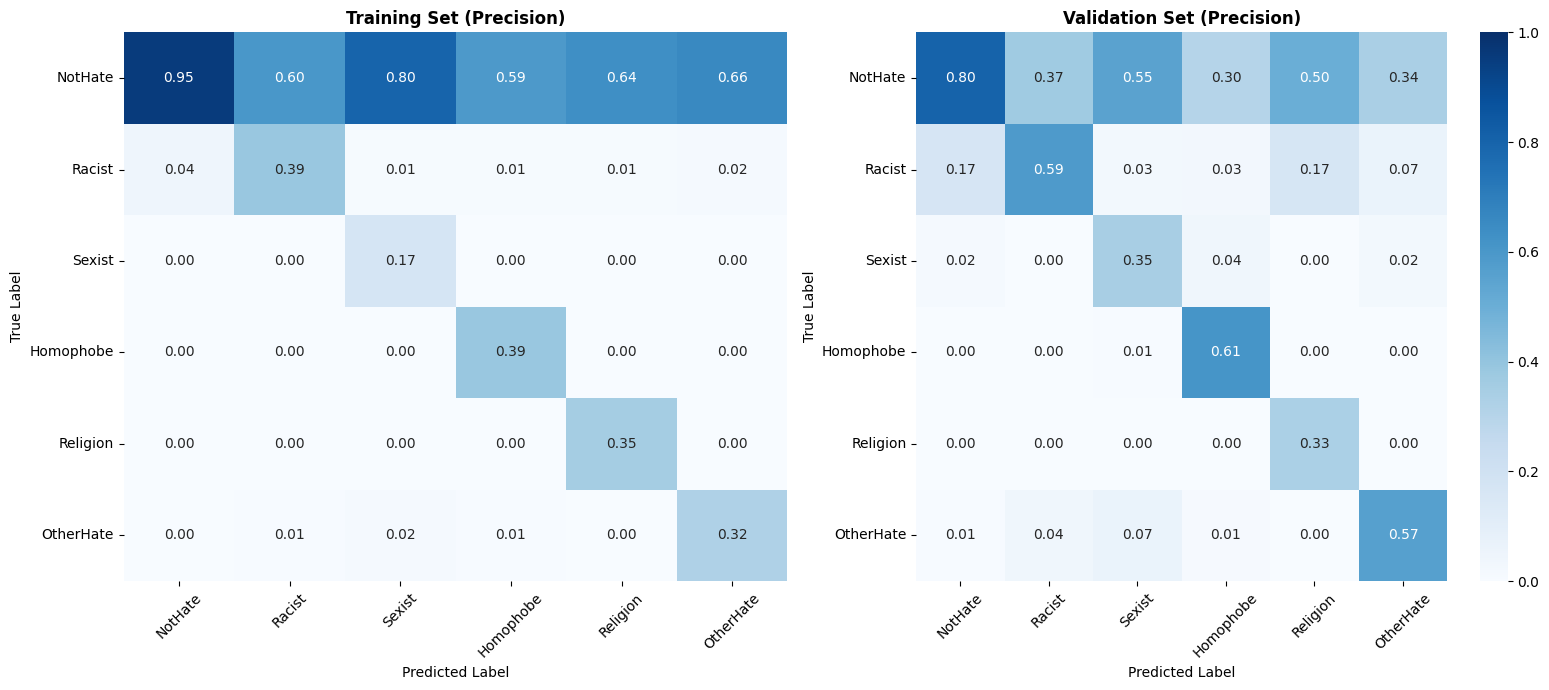

In [18]:
# Derive plot of confusion matrices (train, validation) for Precision
confusion_plot_precision = plot_side_by_side_confusion_matrices(
    y_train_true=y_train,
    y_train_pred=train_pred_classes_xgb_tfidf_tuned,
    y_val_true=y_val,
    y_val_pred=val_pred_classes_xgb_tfidf_tuned,
    class_names=label_values,
    metric='precision'  # 'precision' or 'recall'
)

In [19]:
# Save plot
confusion_plot_precision.savefig(os.path.join(drive_reports_dir, 'confusion_matrices_precision.jpg'), dpi=300, bbox_inches="tight", facecolor="white")

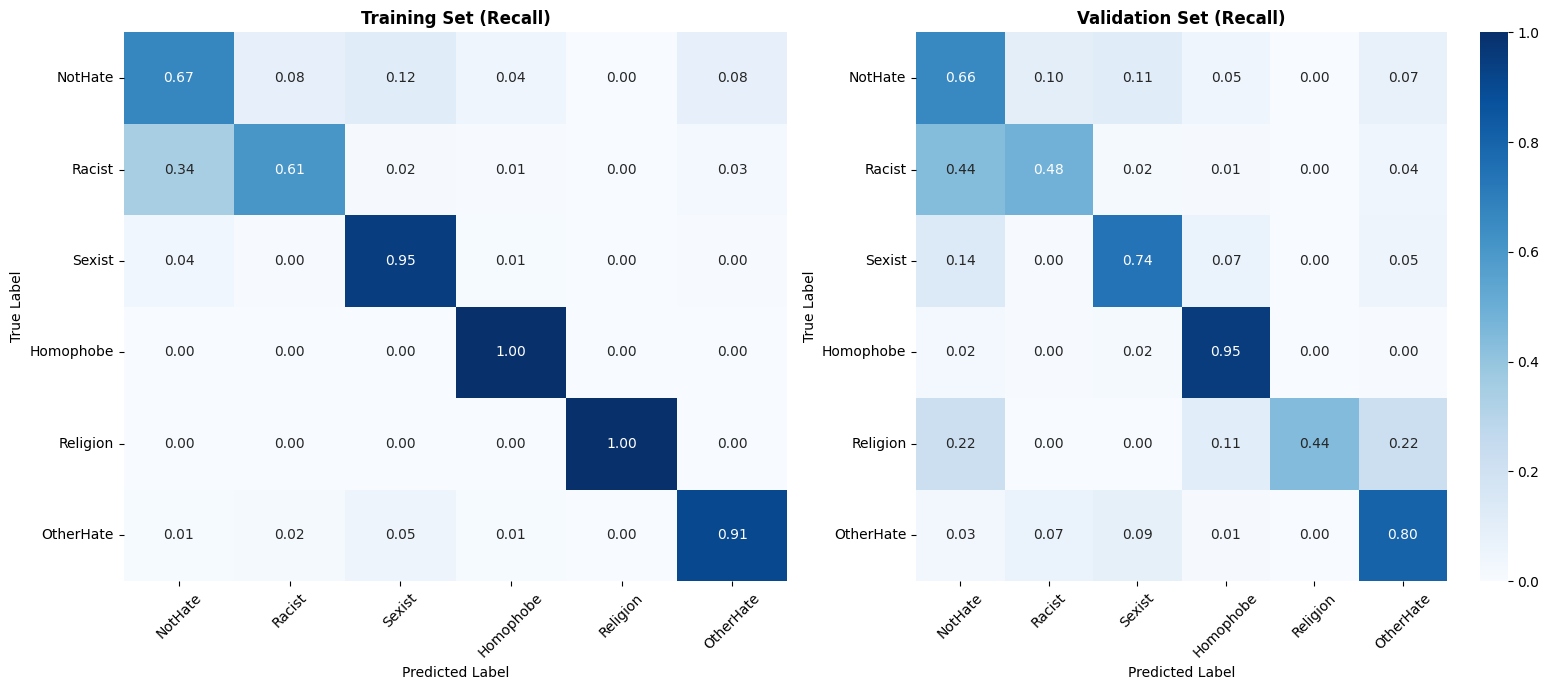

In [21]:
# Derive plot of confusion matrices (train, validation) for Recall
confusion_plot_recall = plot_side_by_side_confusion_matrices(
    y_train_true=y_train,
    y_train_pred=train_pred_classes_xgb_tfidf_tuned,
    y_val_true=y_val,
    y_val_pred=val_pred_classes_xgb_tfidf_tuned,
    class_names=label_values,
    metric='recall'  # 'precision' or 'recall'
)

In [22]:
# Save plot
confusion_plot_recall.savefig(os.path.join(drive_reports_dir, 'confusion_matrices_recall.jpg'), dpi=300, bbox_inches="tight", facecolor="white")

**Загальні висновки**:

З Confusion matrices для Recall видно, що модель дещо гірше вгадувала малочисельні класи у тренувальному наборі, а на валідаційних даних її точність для малочисельних класів була вищою. Цей факт пояснює те, що macro F1-score є вищим на валідаційних даних ніж на тренувальних. На графіку видно, що у тренувальному і валідаційному наборах модель зазвичай або вгадує клас правильно, або визначає його як NotHate. У випадках Sexist та Religion модель неспроможна передбачити правильний клас у половини спостережень у валідаційних даних, а на тренувальних даних якість передбачень є ще гіршою.

Серед малочисельнх класів найкраще передбачуваними класами є `Homophobe`, а також у деякій мірі `Racist` - вони мають достатньо високі стабільні показники Precision та Recall на обох наборах даних. Високі показники Recall і низькі Precision, так як напр. у `Religion`, говорять про те, що модель має тенденцію забагато передбачати даний клас (при цьому і вгадує правильну мітку частіше).   



### Feature importance

In [ ]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_names_tfidf,
    'importance': model_xgb_tfidf_tuned.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(20)

,feature,importance
4746,islam,0.010123
6195,nigger,0.009943
8923,trahunt,0.009580
864,allah,0.008509
3422,faggot,0.008017
7343,retard,0.007725
3095,dyke,0.007632
6019,muslim,0.006568
6141,net,0.005996
4325,hijab,0.005624


Перша 20-ка найважливіших ознак оптимізованої моделі є дуже показовою: майже всі слова, за дуже рідким виключенням, можна однозначно віднести до Hate Speech. Також для багатьох з цих слів можна визначити конкретну категорію мови ненависті, яку і мала визначити модель.

## Model performance on test data

In [23]:
# Predict labels for train and validation data
test_pred_classes_xgb_tfidf_tuned = model_xgb_tfidf_tuned.predict(X_test_tfidf_processed_matrix)

In [24]:
# Evaluate model's performance on train data
print(classification_report(y_test, test_pred_classes_xgb_tfidf_tuned, target_names=list(label_map.values())))

              precision    recall  f1-score   support

     NotHate       0.81      0.65      0.72      4999
      Racist       0.63      0.50      0.56      1613
      Sexist       0.31      0.75      0.43       464
   Homophobe       0.63      0.94      0.76       531
    Religion       0.43      0.54      0.48        24
   OtherHate       0.54      0.78      0.64       780

    accuracy                           0.66      8411
   macro avg       0.56      0.69      0.60      8411
weighted avg       0.71      0.66      0.67      8411



In [32]:
# Other results for comparison
results_df

,Model_name,Hyperparameters,Macro_F1_train,Macro_F1_val,Weighted_F1_train,Weighted_F1_val
0,BoW + Log. reg. (baseline),"{'C': 0.1, 'class_weight': 'balanced', 'dual':...",0.4711,0.5389,0.6791,0.6208
1,TF-IDF + XGBoost,"{'objective': 'multi:softprob', 'base_score': ...",0.4571,0.5827,0.7096,0.6628
2,RoBERTa + XGBoost,"{'objective': 'multi:softprob', 'base_score': ...",0.4415,0.4875,0.6744,0.5913
3,TF-IDF(ngram) + Linear SVC,"{'C': 0.01, 'class_weight': 'balanced', 'dual'...",0.4613,0.5507,0.7978,0.6677
4,RoBERTa + Linear SVC,"{'C': 0.01, 'class_weight': 'balanced', 'dual'...",0.4418,0.4927,0.7905,0.6536
5,RoBERTa + SGDClassifier,"{'alpha': 0.0001, 'average': False, 'class_wei...",0.4016,0.4513,0.7781,0.6341
6,TF-IDF + XGBoost tuned,"{'objective': 'multi:softprob', 'base_score': ...",0.5191,0.5866,0.7358,0.6691


По `macro avg F1-score` вибрана модель TF-IDF + XGBoost tuned  на тестових даних показала дуже схожий результат порівняно з тренувальними і валідаційними даними: 0.60 (тест.) проти 0.52 (трен.) та 0.59 (вал.). Такі самі висновки можемо зробити і у випадку вторинної метрики `weighted avg F1-score`: 0.67 (тест.) проти 0.74 (трен.) та 0.67 (вал.). Загалом модель не демонструє ознак перенавчання чи недонавчання і має стабільно гарну здатність до генералізації даних.

## Overall Conclusions

Загалом, усі розглянуті моделі показали порівняно схожий стабільний результат без ознак перенавчання. Це може вакзувати на те, що сама структура даних є такою, що моделі різних типів можуть її однаково стабільно розпізнати.

З маленьким відривом найкраще спрацювала модель TF-IDF+XGBoost. Незначне покращення результату вдалося досягнути після опимізації її гіперпараметрів.

Щодо самого значення метрики оцінювання `macro avg F1-score`, воно є достатньо низьким для всіх моделей. Деякі фактори можуть обумовлювати таку поведінку. Наприклад, відсутність у даних розмежування цільових класів. Так як деякі класи у даній задачі є дуже близькими по суті, їх природньо дуже важко розділити.    

Іншою причиною може бути те, що використаний набір характеристик та/або поточна методологія обробки та кодування даних не дозволили моделям розмежувати цільові класи достатнім чином, щоб виділити і узагальнити цільові групи. У цьому випадку можна синтезувати більше характеристик з наявних даних і провести їх аналіз, а також зробити зміни у препроцессинг даних, напр. застосувати інші методи для очищення так кодування текстових даних.

Також на якість передбачень значиним чином впливає і точність міток ціьових класів. Під час EDA було помічено, що частина міток, зроблених експертами для повідомлень у датасеті, не є точною чи правдивою. Логічним у цьому випадку є застосування інструментів для покращення якості міток, напр. агентів та інших засобів для розмітки даних.

Завдяки достатньо стабільному посередньому результату, модель може повноправно використовуватись для попередньої фільтрації токсичних повідомлень, які потім можуть відправлятись на дообробку більш деталізованими та ресурсозатратними інструментами або командою адміністраторів.